In [2]:
#Imputing the dataset
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

In [3]:
#Reading the dataset in .csv format
df = pd.read_csv("data.csv")

In [4]:
#Finding out of column with missing values
cols_with_missing = [col for col in df.columns
                     if df[col].isnull().any()]

In [6]:
#Printing columns with missing  values in list
cols_with_missing

['AGE_6',
 'MJH',
 'EVERWORK',
 'FTPTLAST',
 'COWMAIN',
 'NAICS_21',
 'NOC_10',
 'NOC_43',
 'YABSENT',
 'WKSAWAY',
 'PAYAWAY',
 'UHRSMAIN',
 'AHRSMAIN',
 'FTPTMAIN',
 'UTOTHRS',
 'ATOTHRS',
 'HRSAWAY',
 'YAWAY',
 'PAIDOT',
 'UNPAIDOT',
 'XTRAHRS',
 'WHYPT',
 'TENURE',
 'PREVTEN',
 'HRLYEARN',
 'UNION',
 'PERMTEMP',
 'ESTSIZE',
 'FIRMSIZE',
 'DURUNEMP',
 'FLOWUNEM',
 'UNEMFTPT',
 'WHYLEFTO',
 'WHYLEFTN',
 'DURJLESS',
 'AVAILABL',
 'LKPUBAG',
 'LKEMPLOY',
 'LKRELS',
 'LKATADS',
 'LKANSADS',
 'LKOTHERN',
 'PRIORACT',
 'YNOLOOK',
 'TLOLOOK',
 'SCHOOLN',
 'AGYOWNK']

In [7]:
#Transformation function
my_imputer = SimpleImputer()
imputed_df = pd.DataFrame(my_imputer.fit_transform(df))
imputed_df.columns = df.columns

In [8]:
#printing data frame
my_imputer = SimpleImputer()
imputed_df = pd.DataFrame(my_imputer.fit_transform(df))
imputed_df.columns = df.columns

In [9]:
#Rounding off the imputed values to the nearest Integer
for col in cols_with_missing:
    imputed_df[col] = imputed_df[col].round(0).astype(int)


In [10]:
#printing Imputed data frame
imputed_df

,REC_NUM,SURVYEAR,SURVMNTH,LFSSTAT,PROV,CMA,AGE_12,AGE_6,GENDER,MARSTAT,...,LKATADS,LKANSADS,LKOTHERN,PRIORACT,YNOLOOK,TLOLOOK,SCHOOLN,EFAMTYPE,AGYOWNK,FINALWT
0,1.0,2025.0,2.0,4.0,24.0,2.0,12.0,4,1.0,3.0,...,1,1,1,2,3,2,1,18.0,2,267.0
1,2.0,2025.0,2.0,1.0,35.0,4.0,4.0,4,2.0,1.0,...,1,1,1,2,3,2,1,8.0,2,419.0
2,3.0,2025.0,2.0,1.0,35.0,4.0,6.0,4,2.0,1.0,...,1,1,1,2,3,2,1,3.0,2,344.0
3,4.0,2025.0,2.0,4.0,47.0,0.0,12.0,4,1.0,1.0,...,1,1,1,2,3,2,1,11.0,2,104.0
4,5.0,2025.0,2.0,1.0,24.0,2.0,7.0,4,2.0,2.0,...,1,1,1,2,3,2,1,14.0,3,195.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113775,113776.0,2025.0,2.0,1.0,24.0,1.0,4.0,4,2.0,1.0,...,1,1,1,2,3,2,1,2.0,2,314.0
113776,113777.0,2025.0,2.0,1.0,35.0,4.0,3.0,5,1.0,6.0,...,1,1,1,2,3,2,1,2.0,2,325.0
113777,113778.0,2025.0,2.0,1.0,35.0,4.0,8.0,4,1.0,1.0,...,1,1,1,2,3,2,1,7.0,4,255.0
113778,113779.0,2025.0,2.0,4.0,13.0,0.0,12.0,4,1.0,1.0,...,1,1,1,2,3,2,1,11.0,2,81.0


In [13]:
#Importing libraries for visualization of data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [14]:
#Creating a sunburst chart
# Load the dataset (adjust path as needed)
data_path = 'data.xlsx'
df = pd.read_excel(data_path)


# Map coded values to meaningful labels (based on codebook)
gender_map = {1: 'Men+', 2: 'Women+'}
lfsstat_map = {1: 'Employed, at work', 2: 'Employed, absent', 3: 'Unemployed', 4: 'Not in labour force'}
marstat_map = {1: 'Married', 2: 'Living in common-law', 3: 'Widowed', 4: 'Separated', 5: 'Divorced', 6: 'Single'}


df['GENDER'] = df['GENDER'].map(gender_map)
df['LFSSTAT'] = df['LFSSTAT'].map(lfsstat_map)
df['MARSTAT'] = df['MARSTAT'].map(marstat_map)


# Filter data to remove missing values for relevant columns
filtered_df = df.dropna(subset=['GENDER', 'LFSSTAT', 'MARSTAT'])


# Create sunburst chart
fig = px.sunburst(
    filtered_df,
    path=['GENDER', 'LFSSTAT', 'MARSTAT'],  # Hierarchical layers
    title="Sunburst Chart of Gender, Labour Force Status, and Marital Status",
    width=800,
    height=800
)


# Show the chart
fig.show()

In [16]:
#Loading data
df = pd.read_excel('data.xlsx')
codebook = pd.read_excel('LFS_PUMF_EPA_FGMD_codebook_formatted.xlsx', sheet_name='LFS_PUMF_EPA_FGMD_codebook')


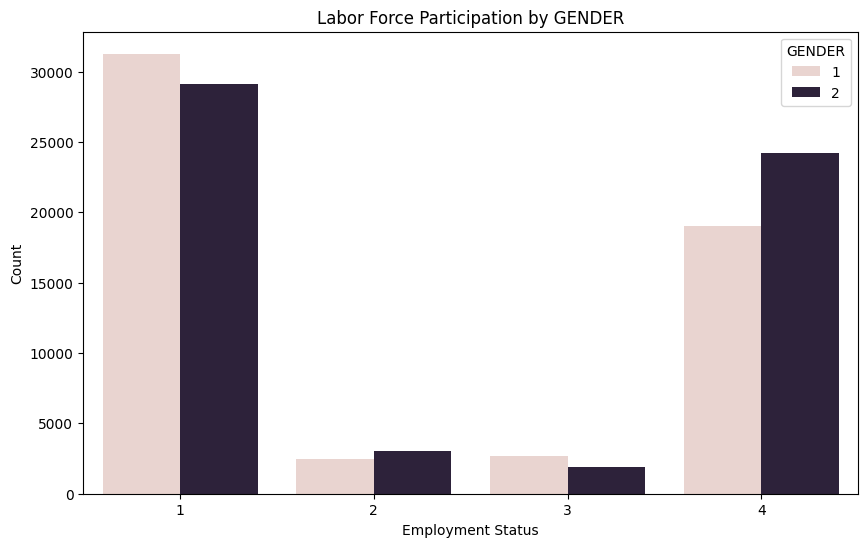

In [17]:
#Gender distribution in Labour Force Data (LFS)
plt.figure(figsize=(10,6))
sns.countplot(x='LFSSTAT', hue='GENDER', data=df)
plt.title('Labor Force Participation by GENDER')
plt.xlabel('Employment Status')
plt.ylabel('Count')
plt.show()

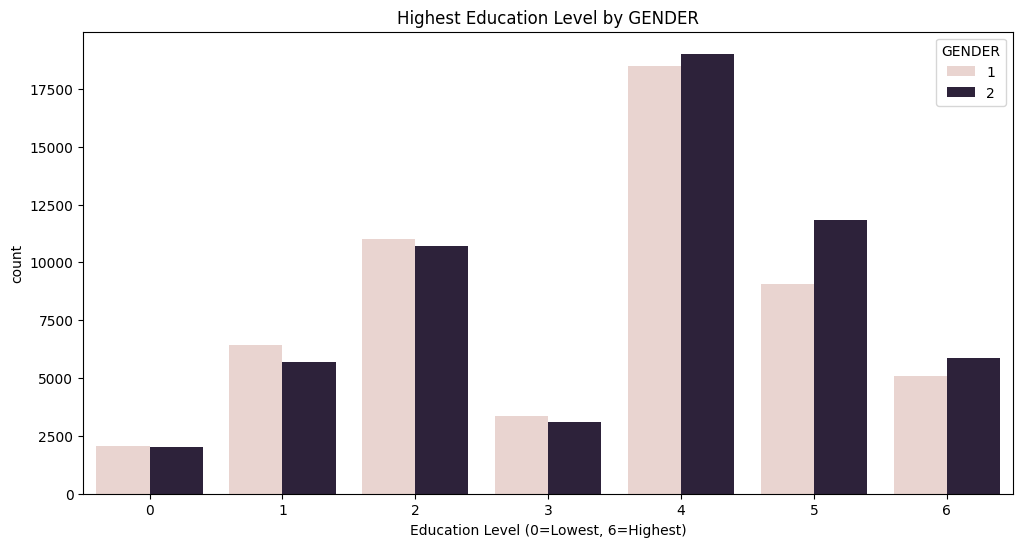

In [18]:
#Education vs Employment
plt.figure(figsize=(12,6))
educ_order = ['0', '1', '2', '3', '4', '5', '6']
sns.countplot(x='EDUC', hue='GENDER', data=df, order=educ_order)
plt.title('Highest Education Level by GENDER')
plt.xlabel('Education Level (0=Lowest, 6=Highest)')
plt.show()

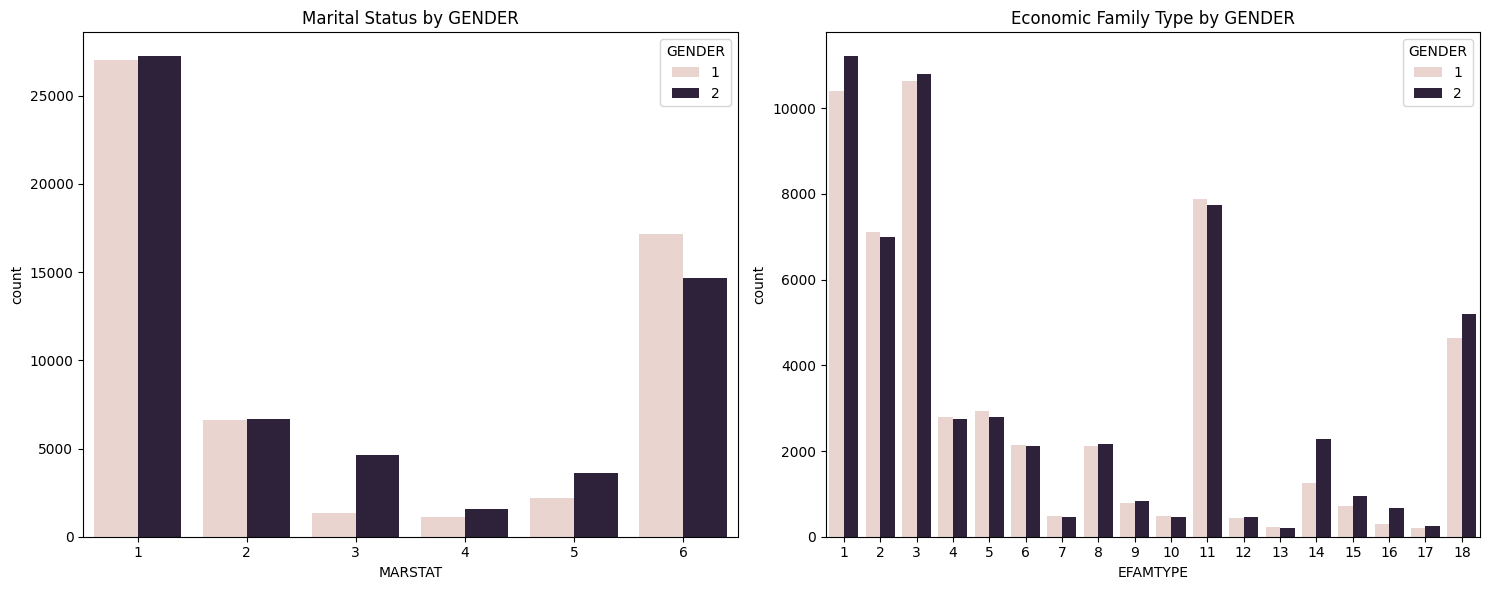

In [19]:
#Family Status Impact
fig, ax = plt.subplots(1,2, figsize=(15,6))
sns.countplot(x='MARSTAT', hue='GENDER', data=df, ax=ax[0])
sns.countplot(x='EFAMTYPE', hue='GENDER', data=df, ax=ax[1])
ax[0].set_title('Marital Status by GENDER')
ax[1].set_title('Economic Family Type by GENDER')
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

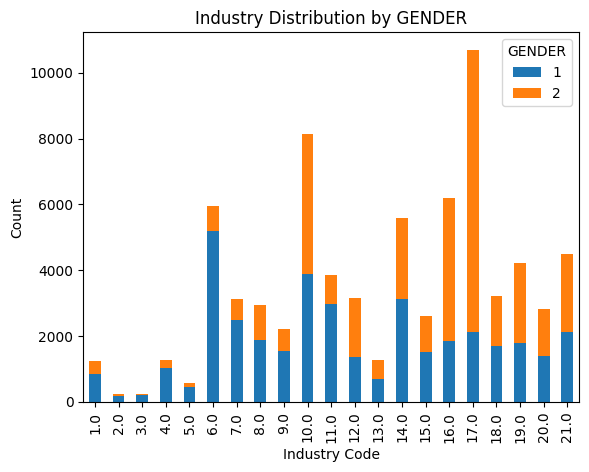

In [20]:
#Industry distribution
plt.figure(figsize=(14,8))
industry_counts = df.groupby(['NAICS_21', 'GENDER']).size().unstack()
industry_counts.plot(kind='bar', stacked=True)
plt.title('Industry Distribution by GENDER')
plt.xlabel('Industry Code')
plt.ylabel('Count')
plt.show()

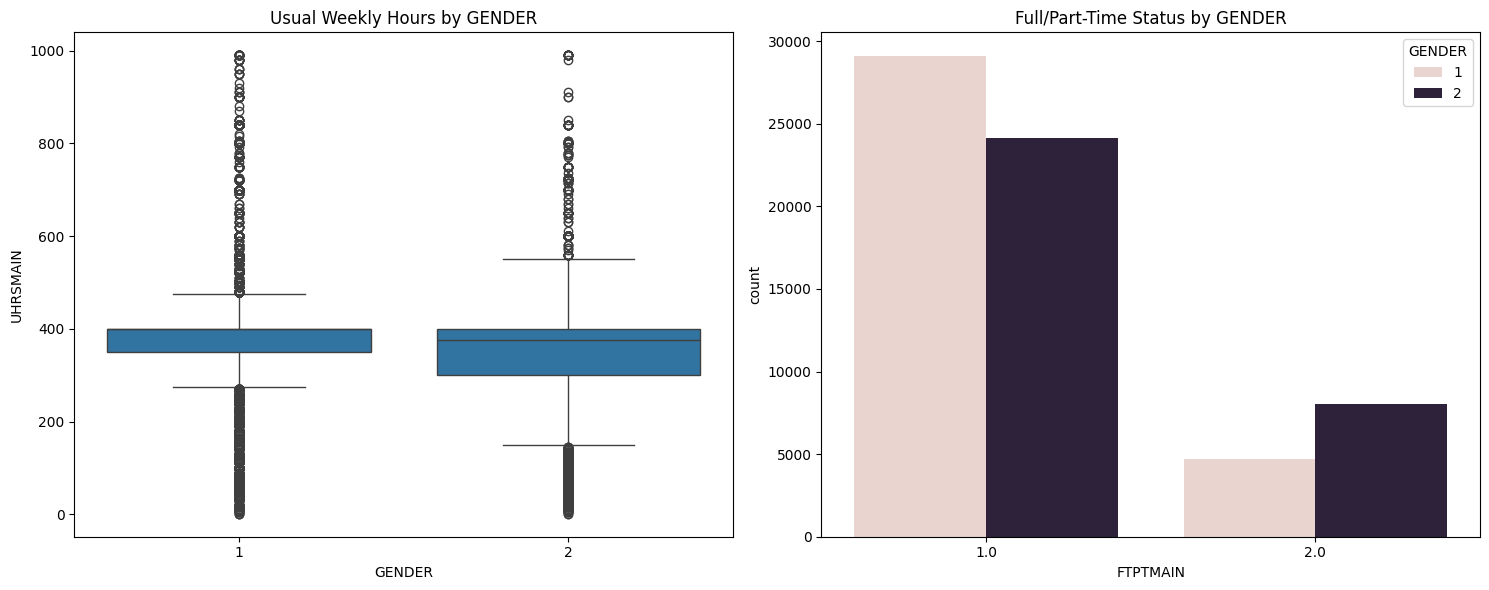

<Figure size 1200x600 with 0 Axes>

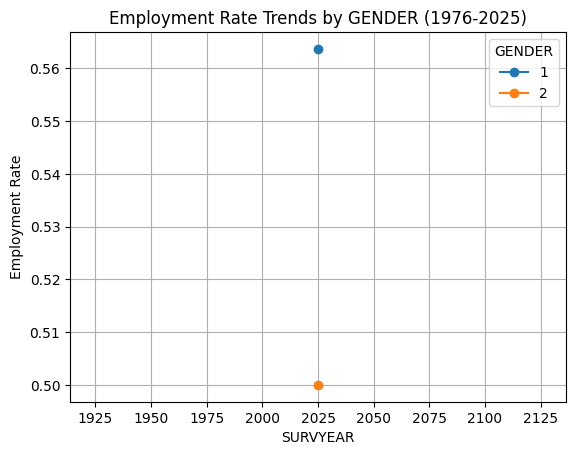

In [21]:
#Work Pattern analysis
fig, ax = plt.subplots(1,2, figsize=(15,6))
sns.boxplot(x='GENDER', y='UHRSMAIN', data=df, ax=ax[0])
sns.countplot(x='FTPTMAIN', hue='GENDER', data=df, ax=ax[1])
ax[0].set_title('Usual Weekly Hours by GENDER')
ax[1].set_title('Full/Part-Time Status by GENDER')
plt.tight_layout()
plt.show()
#Line Chart: Labour Force Participation Trends
plt.figure(figsize=(12,6))
(df.groupby(['SURVYEAR', 'GENDER'])['LFSSTAT']
   .value_counts(normalize=True)
   .unstack()
   .loc[:, 1]  # Assuming 1=Employed in lfsstat
   .unstack()
   .plot(kind='line', marker='o'))
plt.title('Employment Rate Trends by GENDER (1976-2025)')
plt.ylabel('Employment Rate')
plt.legend(title='GENDER')
plt.grid(True)
plt.show()

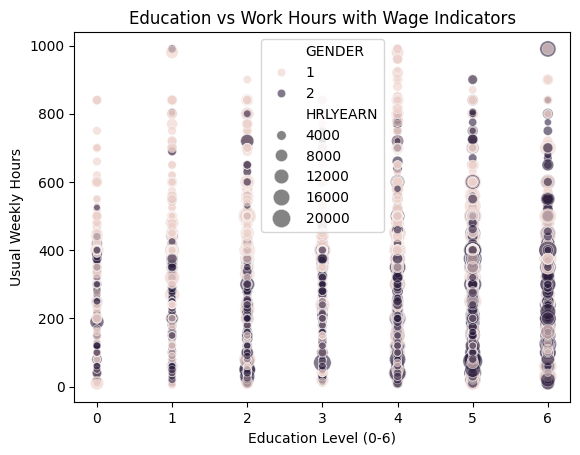

In [22]:
#Scatter Plot:Education vs Hours Worked vs Wages
sns.scatterplot(data=df, x='EDUC', y='UHRSMAIN', hue='GENDER',
                size='HRLYEARN', sizes=(20, 200), alpha=0.6)
plt.title('Education vs Work Hours with Wage Indicators')
plt.xlabel('Education Level (0-6)')
plt.ylabel('Usual Weekly Hours')
plt.show()

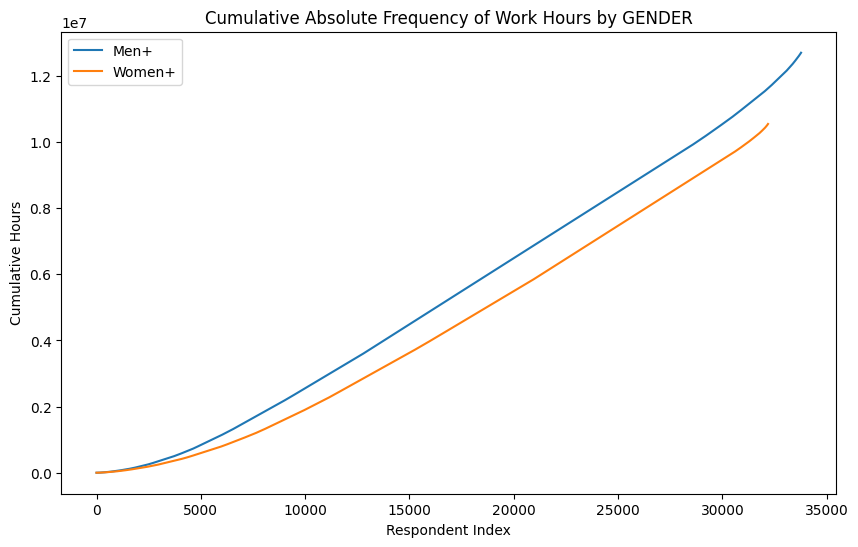

In [23]:
#Cumulative Distribution :Work Hours
plt.figure(figsize=(10,6))
for GENDER in df['GENDER'].unique():
    subset = df[df['GENDER'] == GENDER]['UHRSMAIN'].dropna()
    subset.sort_values().reset_index(drop=True).cumsum().plot()
plt.title('Cumulative Absolute Frequency of Work Hours by GENDER')
plt.xlabel('Respondent Index')
plt.ylabel('Cumulative Hours')
plt.legend(['Men+', 'Women+'])
plt.show()

In [ ]:
#Pairwise Scatter Matrix
variables = ['EDUC', 'AGE_12', 'UHRSMAIN', 'HRLYEARN']
sns.pairplot(df[variables + ['GENDER']].dropna(),
             hue='GENDER', diag_kind='kde',
             plot_kws={'alpha':0.5})
plt.suptitle('Pairwise Relationships of Key Variables')
plt.tight_layout()
plt.show()

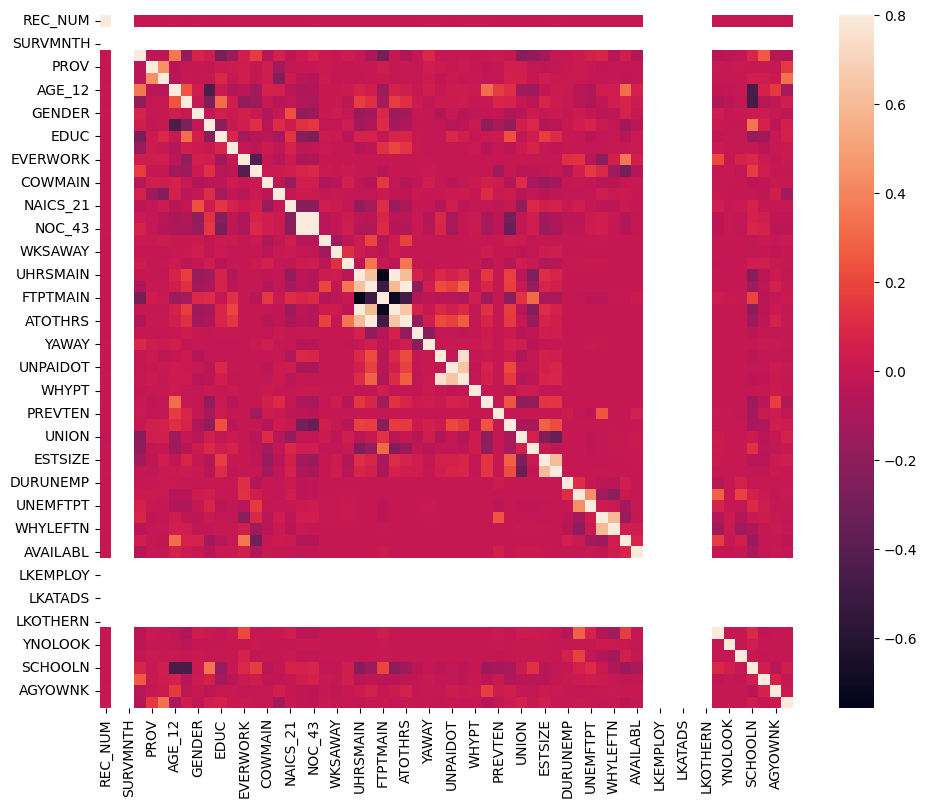

In [26]:
import matplotlib.pyplot as plt
corr_matrix = imputed_df.corr()

f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, vmax=.8, square=True);

<Figure size 1200x600 with 0 Axes>

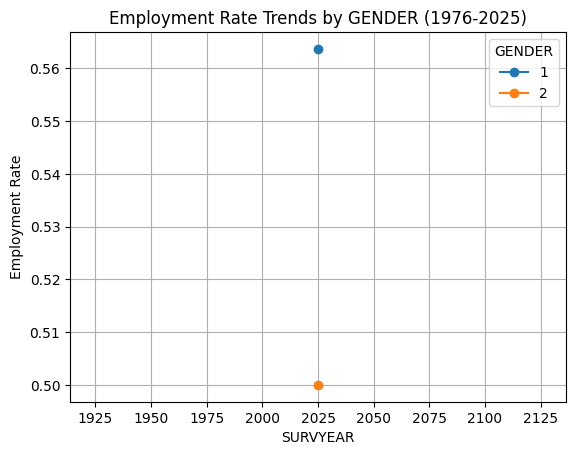

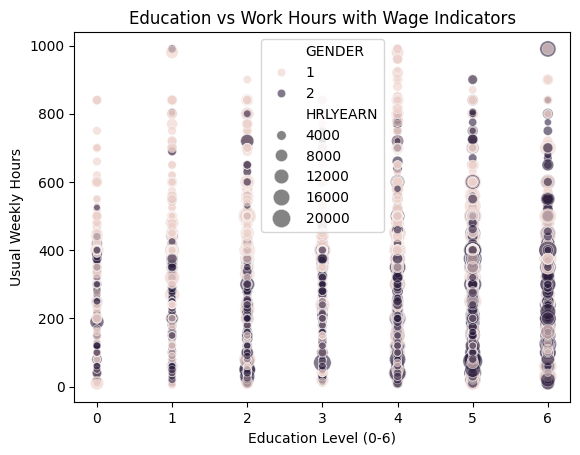

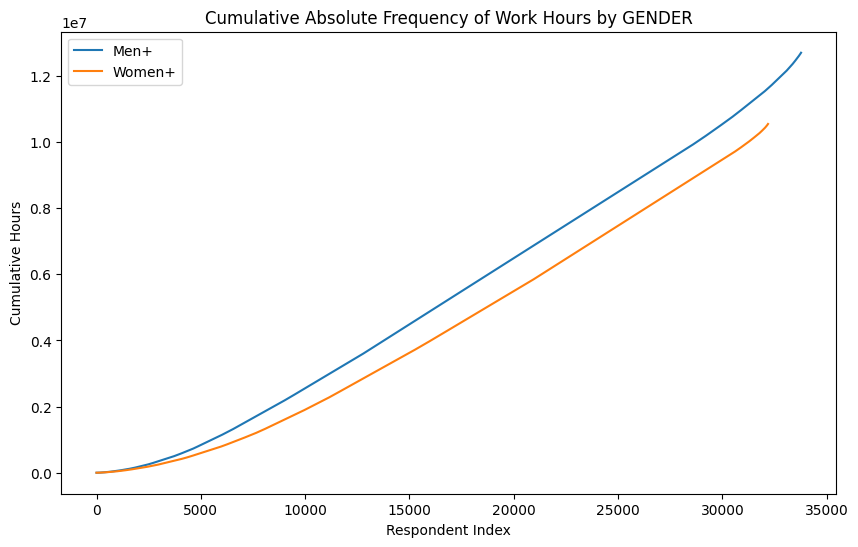

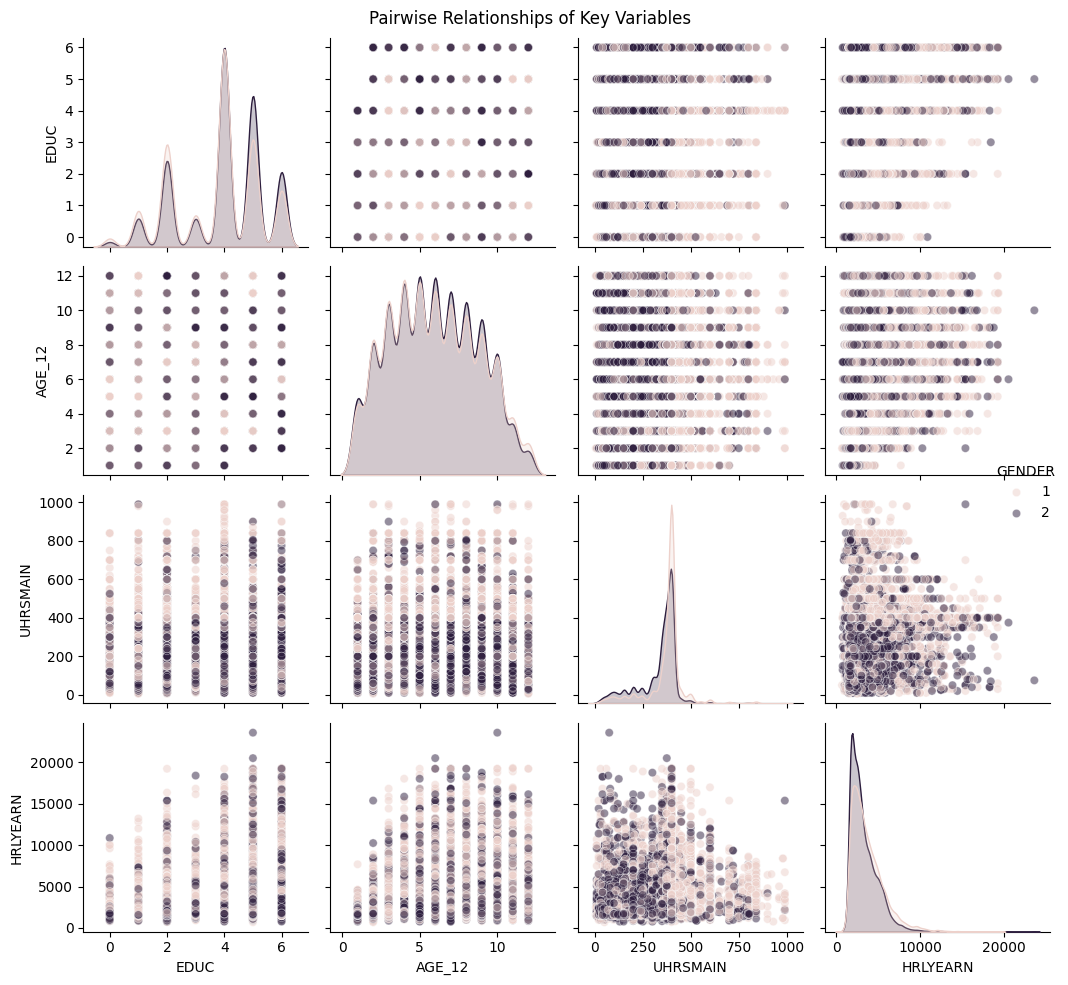

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preparation (hypothetical - actual implementation may vary)
# Assuming 'df' contains the loaded data with codebook variables

# 1. Line Chart: Labor Force Participation Trends
plt.figure(figsize=(12,6))
(df.groupby(['SURVYEAR', 'GENDER'])['LFSSTAT']
   .value_counts(normalize=True)
   .unstack()
   .loc[:, 1]  # Assuming 1=Employed in lfsstat
   .unstack()
   .plot(kind='line', marker='o'))
plt.title('Employment Rate Trends by GENDER (1976-2025)')
plt.ylabel('Employment Rate')
plt.legend(title='GENDER')
plt.grid(True)
plt.show()

# 2. Scatter Plot: Education vs Hours Worked vs Wages
sns.scatterplot(data=df, x='EDUC', y='UHRSMAIN', hue='GENDER',
                size='HRLYEARN', sizes=(20, 200), alpha=0.6)
plt.title('Education vs Work Hours with Wage Indicators')
plt.xlabel('Education Level (0-6)')
plt.ylabel('Usual Weekly Hours')
plt.show()

# 3. Cumulative Distribution: Work Hours
plt.figure(figsize=(10,6))
for GENDER in df['GENDER'].unique():
    subset = df[df['GENDER'] == GENDER]['UHRSMAIN'].dropna()
    subset.sort_values().reset_index(drop=True).cumsum().plot()
plt.title('Cumulative Absolute Frequency of Work Hours by GENDER')
plt.xlabel('Respondent Index')
plt.ylabel('Cumulative Hours')
plt.legend(['Men+', 'Women+'])
plt.show()

# 4. Pairwise Scatter Matrix
variables = ['EDUC', 'AGE_12', 'UHRSMAIN', 'HRLYEARN']
sns.pairplot(df[variables + ['GENDER']].dropna(),
             hue='GENDER', diag_kind='kde',
             plot_kws={'alpha':0.5})
plt.suptitle('Pairwise Relationships of Key Variables')
plt.tight_layout()
plt.show()
